In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from scipy.stats import pearsonr


def scatter_outlier(file_path, pollutant):

    # Membaca data
    df = pd.read_csv(file_path)

    # Cleaning
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[pollutant] = pd.to_numeric(df[pollutant], errors="coerce")

    df = df.dropna(subset=["date", pollutant]).copy()
    df = df.sort_values("date").reset_index(drop=True)

    # Konversi tanggal menjadi angka
    df["date_num"] = (
        df["date"] - df["date"].min()
    ).dt.days

    # Isolation Forest
    model = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    df["prediction"] = model.fit_predict(
        df[[pollutant]]
    )

    # Yes = Outlier, No = Normal
    df["Status"] = df["prediction"].map({
        -1: "Yes",
         1: "No"
    })

    # Pisahkan data
    normal = df[df["Status"] == "No"]
    outlier = df[df["Status"] == "Yes"]

    # =========================
    # Scatter Plot
    # =========================
    plt.figure(figsize=(16, 7))

    # Normal
    plt.scatter(
        normal["date"],
        normal[pollutant],
        label="No",
        alpha=0.7,
        s=55
    )

    # Outlier
    plt.scatter(
        outlier["date"],
        outlier[pollutant],
        label="Yes",
        alpha=0.9,
        s=65
    )

    # =========================
    # Garis regresi Normal
    # =========================
    if len(normal) > 1:

        slope_n, intercept_n = np.polyfit(
            normal["date_num"],
            normal[pollutant],
            1
        )

        x_n = np.linspace(
            normal["date_num"].min(),
            normal["date_num"].max(),
            100
        )

        y_n = slope_n * x_n + intercept_n

        date_n = (
            df["date"].min()
            + pd.to_timedelta(x_n, unit="D")
        )

        r_n, _ = pearsonr(
            normal["date_num"],
            normal[pollutant]
        )

        plt.plot(
            date_n,
            y_n,
            linewidth=2,
            label=f"No (r = {r_n:.2f})"
        )

    # =========================
    # Garis regresi Outlier
    # =========================
    if len(outlier) > 1:

        slope_o, intercept_o = np.polyfit(
            outlier["date_num"],
            outlier[pollutant],
            1
        )

        x_o = np.linspace(
            outlier["date_num"].min(),
            outlier["date_num"].max(),
            100
        )

        y_o = slope_o * x_o + intercept_o

        date_o = (
            df["date"].min()
            + pd.to_timedelta(x_o, unit="D")
        )

        r_o, _ = pearsonr(
            outlier["date_num"],
            outlier[pollutant]
        )

        plt.plot(
            date_o,
            y_o,
            linewidth=2,
            label=f"Yes (r = {r_o:.2f})"
        )

    # =========================
    # Tampilan
    # =========================
    plt.title(
        f"Scatter Plot {pollutant} Lamongan dengan Identifikasi Outlier"
    )

    plt.xlabel("date")
    plt.ylabel(pollutant)

    plt.legend(title="Outlier")
    plt.xticks(rotation=0)
    plt.grid(False)

    plt.tight_layout()
    plt.show()

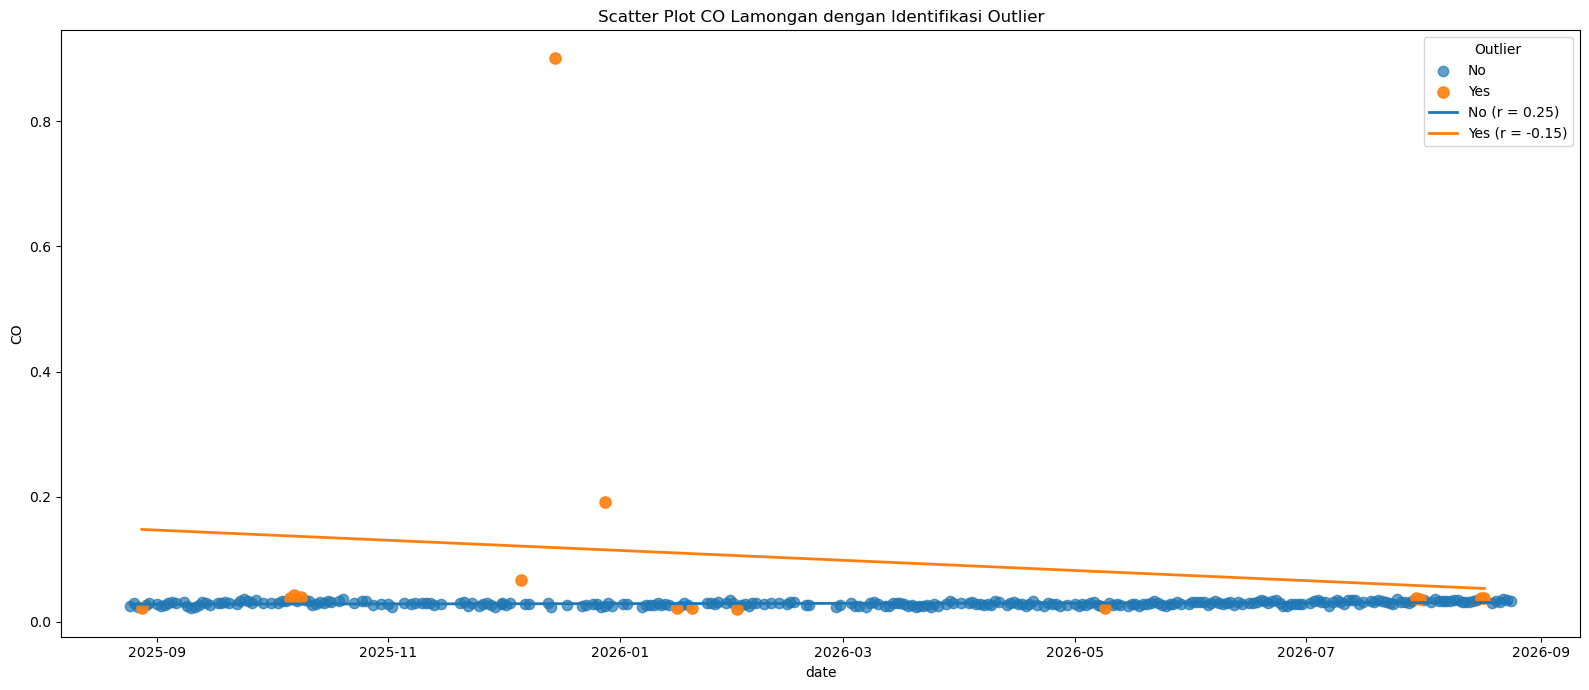

In [5]:
scatter_outlier(
    "CO_lamongan.csv",
    "CO"
)

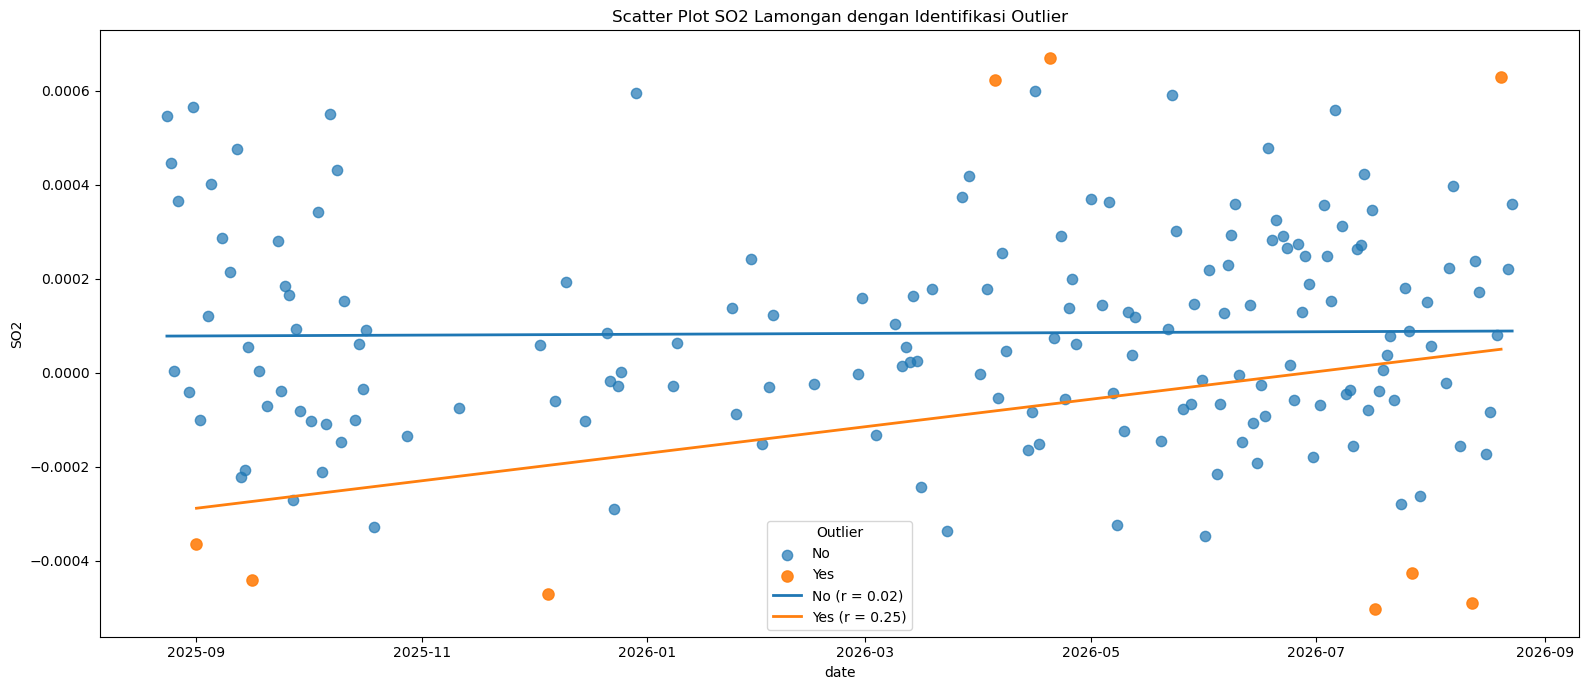

In [6]:
scatter_outlier(
    "SO2_lamongan.csv",
    "SO2"
)

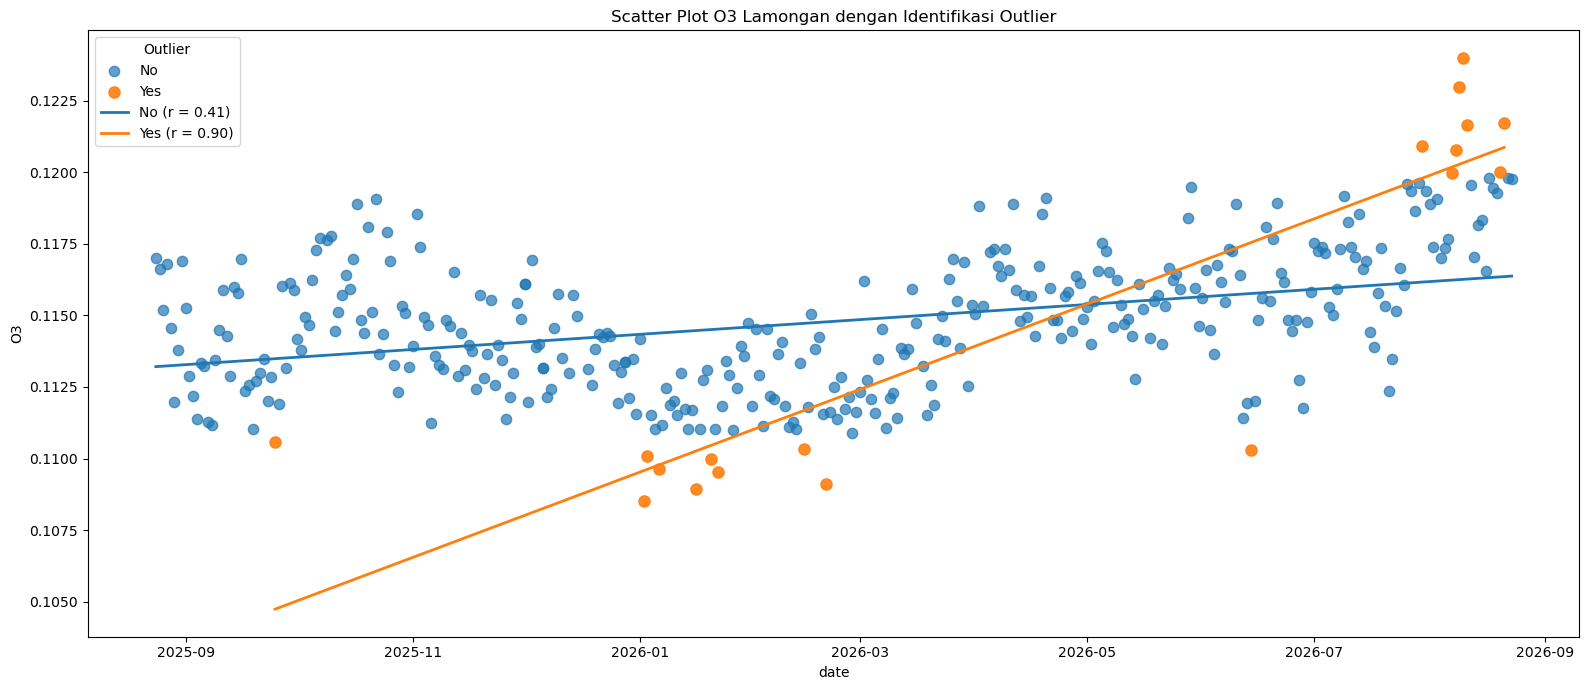

In [8]:
scatter_outlier(
    "O3_lamongan.csv",
    "O3"
)

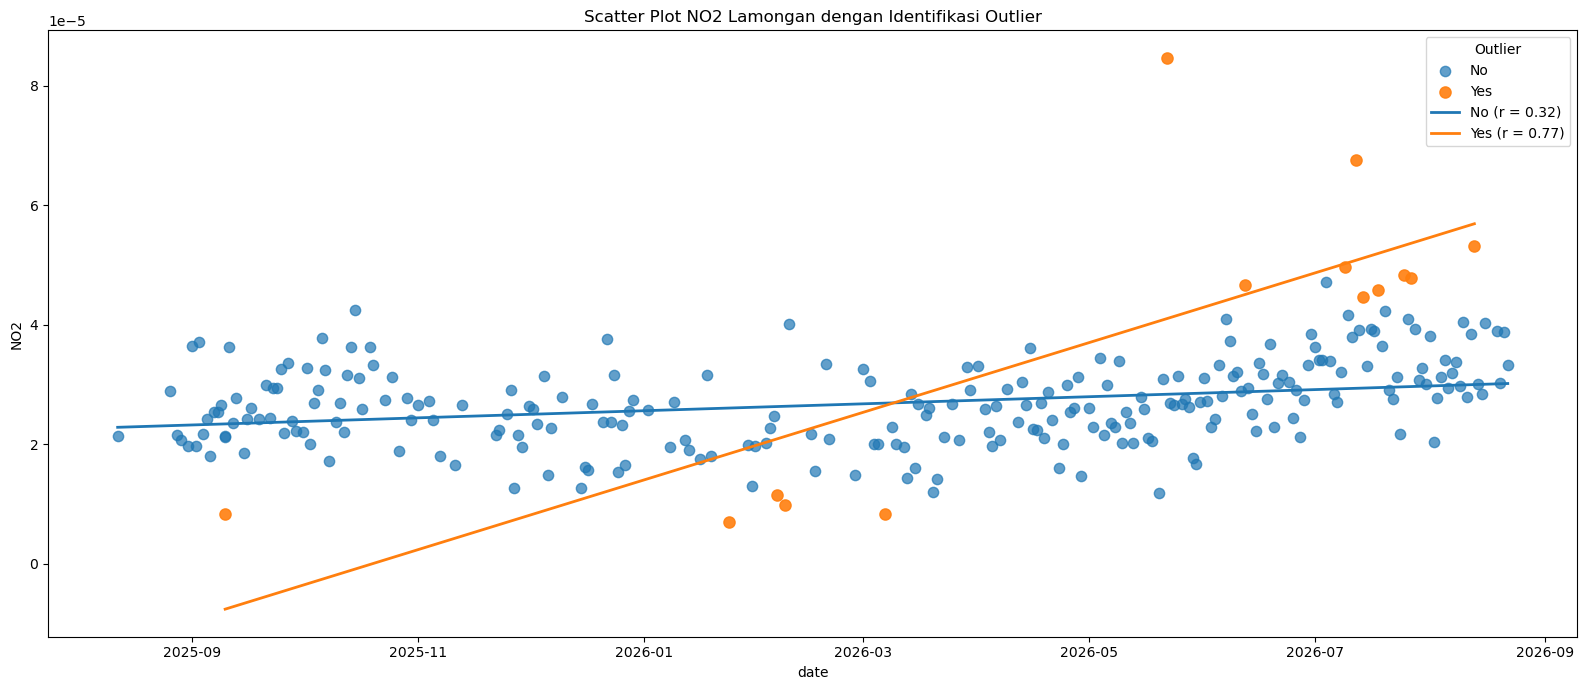

In [9]:
scatter_outlier(
    "No2_lamongan.csv",
    "NO2"
)